# **Fraud Detection**

**Import Library**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

**Read Data**

In [5]:
df=pd.read_csv("/content/Synthetic_Financial_datasets_log.csv")
print(df)

        step      type     amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0          1   PAYMENT    9839.64  C1231006815      170136.00       160296.36   
1          1   PAYMENT    1864.28  C1666544295       21249.00        19384.72   
2          1  TRANSFER     181.00  C1305486145         181.00            0.00   
3          1  CASH_OUT     181.00   C840083671         181.00            0.00   
4          1   PAYMENT   11668.14  C2048537720       41554.00        29885.86   
...      ...       ...        ...          ...            ...             ...   
179009    12   CASH_IN  200271.90  C1829080213     3896164.44      4096436.33   
179010    12   CASH_IN  266616.13  C1119089903     4096436.33      4363052.46   
179011    12   CASH_IN  194735.24   C595356999     4363052.46      4557787.70   
179012    12   CASH_IN   61212.03  C1705359203     4557787.70      4618999.73   
179013    12   CASH_IN      16.00          NaN            NaN             NaN   

           nameDest  oldbal

**EDA**

In [6]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [7]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
179009,12,CASH_IN,200271.90,C1829080213,3896164.44,4096436.33,C1769155229,531167.90,690790.44,0.0,0.0
179010,12,CASH_IN,266616.13,C1119089903,4096436.33,4363052.46,C859300166,6064698.49,6080565.41,0.0,0.0
179011,12,CASH_IN,194735.24,C595356999,4363052.46,4557787.70,C803648645,288407.25,152597.27,0.0,0.0
179012,12,CASH_IN,61212.03,C1705359203,4557787.70,4618999.73,C60296041,2492638.18,2620615.37,0.0,0.0
179013,12,CASH_IN,16.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,179014.000000,1.790140e+05,1.790130e+05,1.790130e+05,1.790130e+05,1.790130e+05,179013.000000,179013.0
mean,9.739222,1.801320e+05,8.915856e+05,9.089488e+05,9.272605e+05,1.188120e+06,0.000776,0.0
std,1.999448,3.335828e+05,2.814423e+06,2.851534e+06,2.374230e+06,2.676059e+06,0.027855,0.0
min,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,9.000000,1.166942e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,10.000000,6.566817e+04,1.976200e+04,0.000000e+00,4.233860e+04,1.163345e+05,0.000000,0.0
75%,11.000000,2.268392e+05,1.935541e+05,2.276798e+05,7.298561e+05,1.166438e+06,0.000000,0.0
max,12.000000,1.000000e+07,3.893942e+07,3.894623e+07,3.903958e+07,3.904248e+07,1.000000,0.0


In [9]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [10]:
df.shape

(179014, 11)

In [11]:
df.size

1969154

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179014 entries, 0 to 179013
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            179014 non-null  int64  
 1   type            179014 non-null  object 
 2   amount          179014 non-null  float64
 3   nameOrig        179013 non-null  object 
 4   oldbalanceOrg   179013 non-null  float64
 5   newbalanceOrig  179013 non-null  float64
 6   nameDest        179013 non-null  object 
 7   oldbalanceDest  179013 non-null  float64
 8   newbalanceDest  179013 non-null  float64
 9   isFraud         179013 non-null  float64
 10  isFlaggedFraud  179013 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 15.0+ MB


In [13]:
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,float64


In [14]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,1
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.fillna(0)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
179009,12,CASH_IN,200271.90,C1829080213,3896164.44,4096436.33,C1769155229,531167.90,690790.44,0.0,0.0
179010,12,CASH_IN,266616.13,C1119089903,4096436.33,4363052.46,C859300166,6064698.49,6080565.41,0.0,0.0
179011,12,CASH_IN,194735.24,C595356999,4363052.46,4557787.70,C803648645,288407.25,152597.27,0.0,0.0
179012,12,CASH_IN,61212.03,C1705359203,4557787.70,4618999.73,C60296041,2492638.18,2620615.37,0.0,0.0


# **Visualization**

**Styling**

In [69]:
sns.set_theme(style="darkgrid")

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14

**Count Plot**

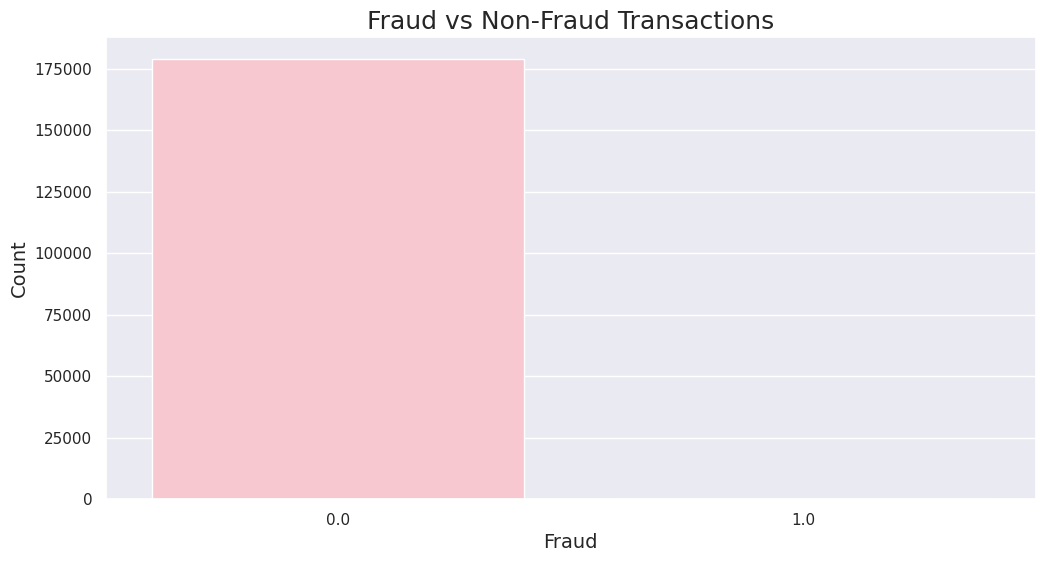

In [70]:
sns.countplot(x='isFraud', data=df,color='pink')
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.show()

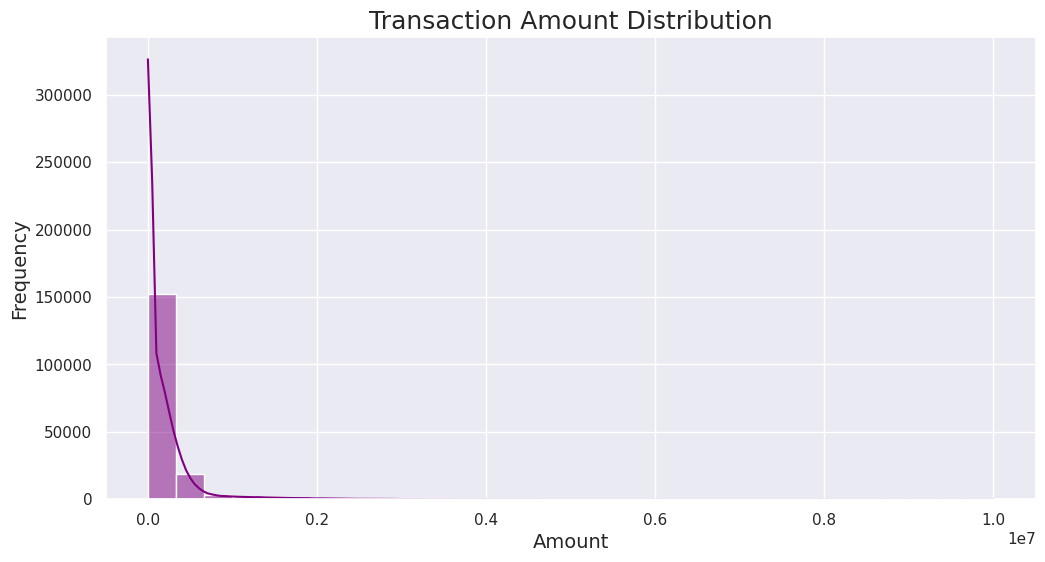

In [71]:
sns.histplot(
    df['amount'],
    bins=30,
    kde=True,
    color='purple'
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

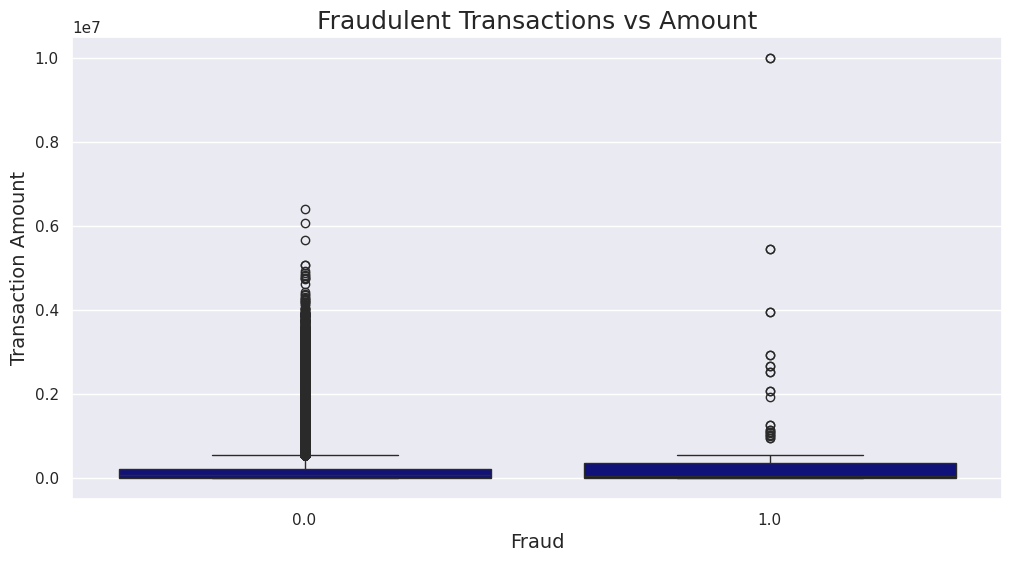

In [72]:
sns.boxplot(
    x='isFraud',
    y='amount',
    data=df,
    color='darkblue'
)

plt.title("Fraudulent Transactions vs Amount")
plt.xlabel("Fraud")
plt.ylabel("Transaction Amount")
plt.show()

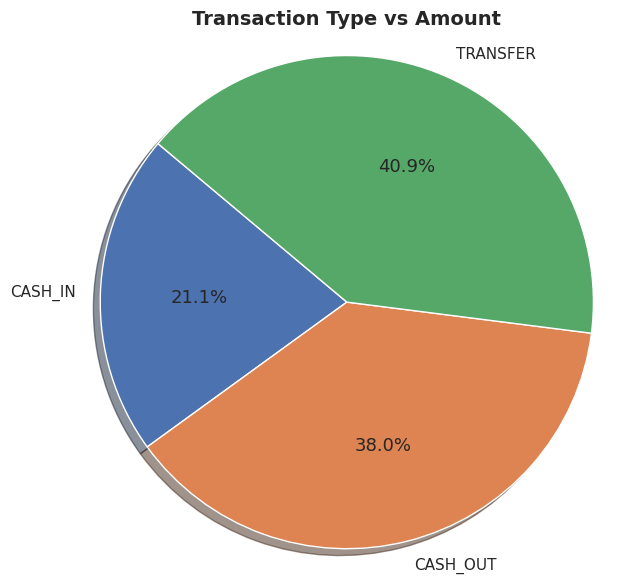

In [73]:
type_amount = df.groupby('type')['amount'].sum()
type_amount = type_amount.drop(['PAYMENT', 'DEBIT'])

plt.figure(figsize=(7,7))

plt.pie(type_amount,
        labels=type_amount.index,
        autopct='%1.1f%%',
        startangle=140,
        shadow=True,
        wedgeprops={'edgecolor': 'white'})

plt.title('Transaction Type vs Amount', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

In [78]:
numeric_cols = [
    'step',
    'amount',
    'isFraud',
    'type'
]

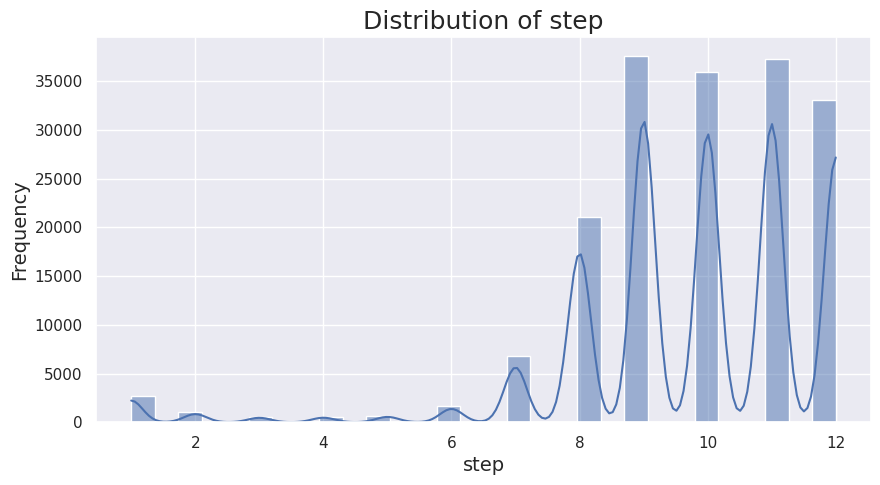

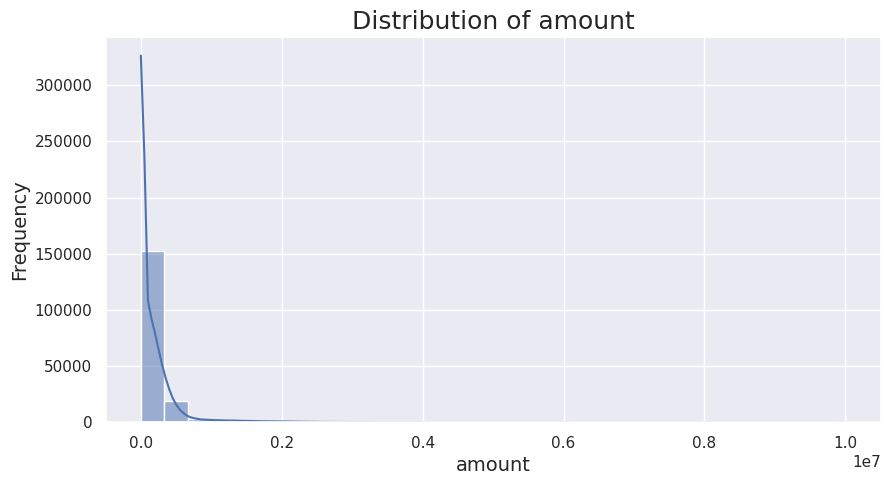

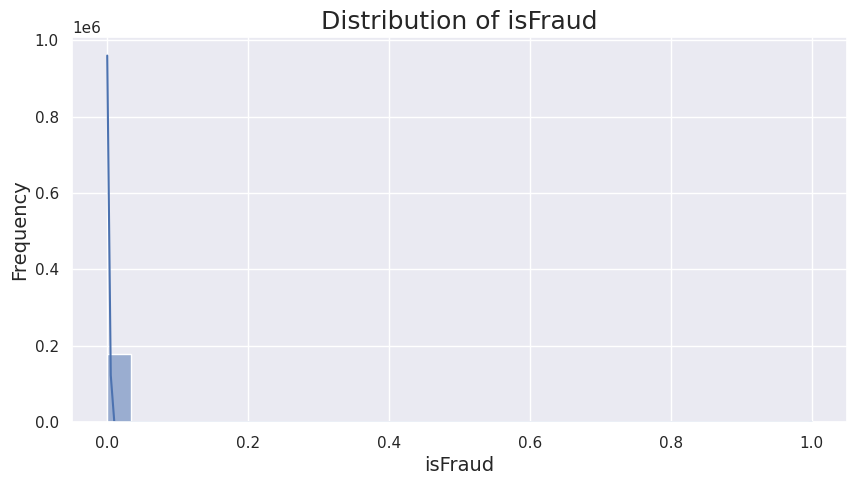

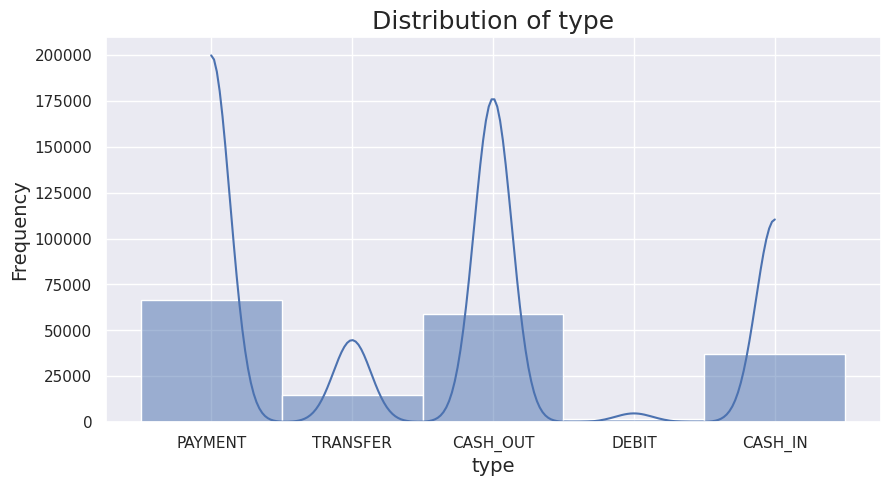

In [79]:
for col in numeric_cols:

    plt.figure(figsize=(10,5))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# **Logistic Regresssion**

In [22]:
X = df[['amount', 'type']]
y = df['isFraud']

In [23]:
X = pd.get_dummies(X, columns=['type'], drop_first=True)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)

In [25]:
print(y_train.isnull().sum())

0


In [26]:
data = pd.concat([X, y], axis=1)

data = data.dropna()

X = data.drop('isFraud', axis=1)
y = data['isFraud']

In [27]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [28]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [29]:
y_pred=model.predict(X_test)

In [30]:
y_prob=model.predict_proba(X_test)[:1]

In [31]:
from sklearn.metrics import (
 accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 roc_auc_score,
 confusion_matrix,
 classification_report
)

In [32]:
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1 Score:",f1_score(y_test, y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred))
print("Classification Report:\n",classification_report(y_test, y_pred))

Accuracy: 0.9994227618054521
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix:
 [[53673     0]
 [   31     0]]
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     53673
         1.0       0.00      0.00      0.00        31

    accuracy                           1.00     53704
   macro avg       0.50      0.50      0.50     53704
weighted avg       1.00      1.00      1.00     53704



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# **Decision Tree**


In [33]:
model1 = DecisionTreeClassifier()
model1.fit(X_train, y_train)

DecisionTreeClassifier()

In [34]:
df_pred = model1.predict(X_test)

In [35]:
df_prob=model1.predict_proba(X_test)

In [36]:
from sklearn.metrics import (
 accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 roc_auc_score,
 confusion_matrix,
 classification_report
)

In [37]:
print("Accuracy:",accuracy_score(y_test, df_pred))
print("Precision:",precision_score(y_test, df_pred))
print("Recall:",recall_score(y_test, df_pred))
print("F1 Score:",f1_score(y_test, df_pred))
print("ROC AUC Score:",roc_auc_score(y_test, df_prob[:, 1]))
print("Confusion Matrix:\n",confusion_matrix(y_test, df_pred))
print("Classification Report:\n",classification_report(y_test, df_pred))

Accuracy: 0.9984917324594071
Precision: 0.05357142857142857
Recall: 0.0967741935483871
F1 Score: 0.06896551724137931
ROC AUC Score: 0.5478849520663661
Confusion Matrix:
 [[53620    53]
 [   28     3]]
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     53673
         1.0       0.05      0.10      0.07        31

    accuracy                           1.00     53704
   macro avg       0.53      0.55      0.53     53704
weighted avg       1.00      1.00      1.00     53704



In [38]:

model_pre = DecisionTreeClassifier(max_depth=4)
model_pre.fit(X_train , y_train)

y_pred_pre = model_pre.predict(X_test)
print("Pre Pruning Accuracy",accuracy_score(y_test,y_pred_pre))

Pre Pruning Accuracy 0.9994227618054521


In [39]:
model_post= DecisionTreeClassifier(ccp_alpha=0.01)
model_post.fit(X_train , y_train)


y_pred_post = model_post.predict(X_test)
print("Post Pruning Accuracy",accuracy_score(y_test,y_pred_post))

Post Pruning Accuracy 0.9994227618054521


In [59]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# **Random Forest**

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [61]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [62]:
rf_pred = model.predict(X_test)

In [63]:
rf_prob=model.predict_proba(X_test)

In [64]:
from sklearn.metrics import (
 accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 roc_auc_score,
 confusion_matrix,
 classification_report
)

In [65]:
print("Accuracy:",accuracy_score(y_test, rf_pred))
print("Precision:",precision_score(y_test, rf_pred))
print("Recall:",recall_score(y_test, rf_pred))
print("F1 Score:",f1_score(y_test, y_pred))
print("ROC AUC Score:",roc_auc_score(y_test, rf_prob[:, 1]))
print("Confusion Matrix:\n",confusion_matrix(y_test, rf_pred))
print("Classification Report:\n",classification_report(y_test, rf_pred))

Accuracy: 0.9985103530463281
Precision: 0.05454545454545454
Recall: 0.0967741935483871
F1 Score: 0.0
ROC AUC Score: 0.6914391389194904
Confusion Matrix:
 [[53621    52]
 [   28     3]]
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     53673
         1.0       0.05      0.10      0.07        31

    accuracy                           1.00     53704
   macro avg       0.53      0.55      0.53     53704
weighted avg       1.00      1.00      1.00     53704



# **Final Result**

**“Random Forest performed better because it detected minority class cases more effectively and achieved the highest ROC-AUC score compared to Logistic Regression and Decision Tree**